# Time-resolved energies and influence spectrum

## Table of contents
<a name="toc"></a>
1. [Importing needed libraries](#import)
2. [Overview of required files](#required_files)
3. [Energy vs time](#ene_time)
4. [Influence spectrum](#inf_spec)
5. [Spectral density](#5)
   
### A. Learning objectives

* To be able to plot the computed excited states energies vs time
* To be able to compute and plot the influence spectrum

### B. Use cases


* [Energy vs time](#ene_time)
* [Influence spectrum](#inf_spec)
* [Spectral density](#5)


### C. Functions

- `libra_py`
  - `influence_spectrum`
    - [`recipe1`](#inf_spec)
  - `packages`
    - `cp2k`
      - `methods`
        - [`extract_energies_sparse`](#ene_time)
  - `units`
    - `au2ev`

## 1. Importing needed libraries <a name="import"></a>
[Back to TOC](#toc)

Here, we import `numpy`, `matplotlib.pyplot`, `CP2K_methods`, and `influence_spectrum`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from liblibra_core import *
import libra_py.packages.cp2k.methods as CP2K_methods
from libra_py import units, influence_spectrum

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 2. Overview of required files <a name="required_files"></a>
[Back to TOC](#toc)

All the energy files are in this folder:

* `data/res-mb-sd-DFT`

In [2]:
!tar -xf data.tar.bz2

## 3. Energy vs time <a name="ene_time"></a>
[Back to TOC](#toc)

Here, we will plot the energies of the many-body and single-particle excitation bases

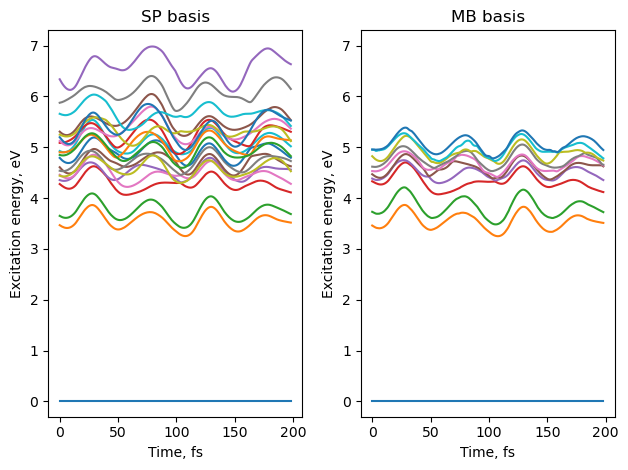

In [3]:
%matplotlib inline
params = {"path_to_energy_files": "data/res-mb-sd-DFT", "dt": 1.0, 
          "prefix": "Hvib_sd_", "suffix": "_re", "istep": 1200, "fstep": 1399}

titles = ['SP basis', 'MB basis']
plt.figure()
for c, basis in enumerate(['sd','ci']):
    plt.subplot(1,2,c+1)
    params.update({"prefix": F"Hvib_{basis}_"})
    md_time, energies = CP2K_methods.extract_energies_sparse(params)
    energies = energies * units.au2ev
    for i in range(energies.shape[1]):
        plt.plot(md_time, energies[:,i]-energies[:,0])
    
    plt.title(titles[c])
    plt.ylabel('Excitation energy, eV')
    plt.xlabel('Time, fs')
    plt.ylim(-0.3, 7.3)
plt.tight_layout()

## 4. Influence spectrum <a name="inf_spec"></a>
[Back to TOC](#toc)

### 4.1. Theoretical Background

#### A. Energy-gap fluctuations

Assume a system observable (often an electronic energy gap) evolves in time:

$$
\Delta E(t)
$$

Define fluctuations around the mean:

$$
\delta E(t)=\Delta E(t)-\langle\Delta E\rangle
$$

where

$$
\langle\Delta E\rangle
=
\frac{1}{T}\int_0^T\Delta E(t)\,dt
$$

These fluctuations encode how the environment perturbs the quantum subsystem.


#### B. Time-domain bath correlation function

The central quantity is the autocorrelation function:

$$
C(t)
=
\langle
\delta E(0)\delta E(t)
\rangle
$$

Properties:

- measures memory of environmental fluctuations
- large correlation time → non-Markovian bath
- short correlation time → Markovian bath

Typical behavior:

$$
C(t)\rightarrow0
\qquad
(t\rightarrow\infty)
$$

#### C. Influence spectrum (noise spectrum)

The **influence spectrum** is the Fourier transform of the correlation function:

$$
I(\omega)
=
\int_{-\infty}^{\infty}
C(t)e^{i\omega t}\,dt
$$

Since equilibrium correlation functions satisfy:

$$
C(t)=C(-t)
$$

the transform reduces to:

$$
I(\omega)
=
2
\int_0^\infty
C(t)\cos(\omega t)\,dt
$$

Interpretation:

- tells **how strongly fluctuations occur at frequency** ( $\omega$ )
- describes environmental noise distribution
- purely classical quantity if derived from classical trajectories

Units:

$$
[I(\omega)]
=
[E]^2\cdot [t]
$$



### 4.2. Practical Part

In order to compute the influence spectrum for the energy gap fluctuations between two states, `i` and `j`. The parameters that need to be passed to the function `influence_spectrum.recipe1` are as follows:

`data`: A list of `MATRIX(ndof, 1)` objects i.e. a sequence of real-valued ndof-dimensional vectors

`dt`: Time step in fs units
    
`wspan`: The window of frequencies for the Fourier transform with units cm$^{-1}$

`dw`: The grid points spacing in the frequency domain with units of cm$^{-1}$

`do_output`: Whether we print out the data the results into files

`acf_filename`: The name of the file where to print the ACF
    
`spectrum_filename`: The name of the file where to print the spectrum 

`do_center`: A flag controlling whether to center data (=`True`) or not (=`False`). Centering means we subtract the average value (over all the data points) from all the data points - this way, we convert values into their fluctuations 

`acf_type`: selector of the convention to to compute ACF:
```
   * 0 : the chemist convention,  (1/(N-h)) Sum_{t=1,N-h} (Y[t]*Y[t+h]) [ default ]
   * 1 : the statistician convention, (1/N) Sum_{t=1,N-h} (Y[t]*Y[t+h])
```

`data_type`: What is the format of the data?
```
        * 0 : list of MATRIX(ndof, 1) [ default ]
        * 1 : list of VECTOR
```

The `recipe1` function returns a tuple of (T, norm_acf, raw_acf, W, J, J2), where:

`T`: List with time axis in `fs` units

`norm_acf`: List with normalized ACF

`raw_acf`: List with un-normalized ACF

`W`: List with frequencies axis with units $cm^{-1}$

`J`: List with amplitudes of Fourier transform

`J2`: List with values of $(1/2\pi)|J|^2$

Select two states of interest to compute the influence spectrum for their energy gap fluctuations. Here we comute that for the ground state, `i=0`, and the first excited state, `j=1` and then plot the spectrum.

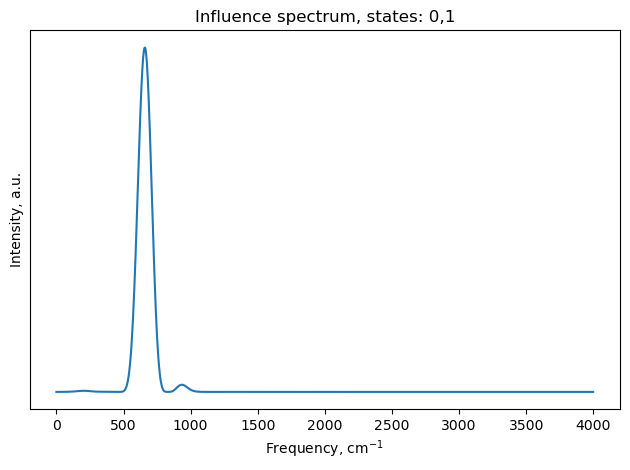

In [4]:
# For computing influence spectra
params_inf_cpec = {"dt": 1.0, "wspan": 4000.0, "dw": 1.0, "do_output": False,
          "do_center": True, "acf_type": 1, "data_type": 0}
# ==========
# Selecting the two states we want to compute the influence spectra for
i = 0; j = 1
# ========== Computing the autocorrelation function and the influence spectra
data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1,1)
    if i<j:
        gap = energies[step,j]-energies[step,i]
    else:
        gap = energies[step,i]-energies[step,j]
    x.set(0,0, gap)
    data_ij.append(x)
Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(data_ij, params_inf_cpec)

plt.plot(Wij, J2ij)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Influence spectrum, states: {i},{j}')
plt.tight_layout()

## 5. Spectral density <a name="5"></a>
[Back to TOC](#toc)

### 5.1. Theoretical Background


#### A. Spectral density

The **spectral density** converts fluctuation strength into effective system–bath coupling.

For a harmonic bath:

$$
J(\omega)
=
\sum_k
g_k^2
\delta(\omega-\omega_k)
$$

where:

- ($g_k$): coupling strength
- ($\omega_k$): bath mode frequency

Continuous limit:

$$
J(\omega)
=
g^2(\omega)\rho(\omega)
$$

where:

- (g($\omega$)): frequency-dependent coupling
- ($\rho(\omega)$): density of bath states


#### B. Relation between influence spectrum and spectral density

For classical energy-gap fluctuations:

$$
J(\omega)
\propto
\beta\omega I(\omega)
$$

or more explicitly:

$$
J(\omega)
=
\frac{\beta\omega}{2}
I(\omega)
$$

with

$$
\beta
=
\frac{1}{k_B T}
$$

Equivalent expression:

$$
J(\omega)
=
\beta\omega
\int_0^\infty
C(t)\cos(\omega t)\,dt
$$

The prefactor imposes approximate quantum detailed balance.

### 5.2. Practical Part

In [5]:
w = np.array(Wij)
J = np.array(Jij)

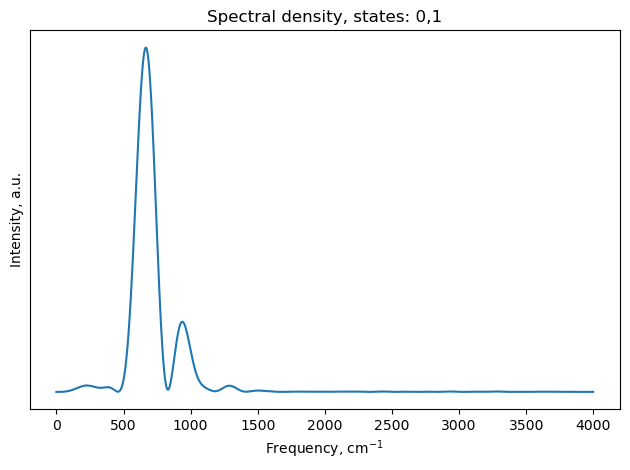

In [6]:
plt.plot(w, J*w)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Spectral density, states: {i},{j}')
plt.tight_layout()

## 6. Reorganization energy<a name="6"></a>
[Back to TOC](#toc)

### 6.1. Theoretical Background

Spectral density determines total environmental coupling:

$$
\lambda
=
\int_0^\infty
\frac{J(\omega)}{\omega}
\,d\omega
$$

(or conventionally with an additional \(1/\pi\))

Interpretation:

- total relaxation energy of the bath
- important in Marcus theory, Redfield, HEOM, spin-boson models


## 7. Modern script<a name="7"></a>
[Back to TOC](#toc)

### 7.1. Gap

[3.460635 3.44581  3.432705 3.42046  3.41265  3.40843  3.40626  3.408315
 3.413335 3.42162  3.433325 3.4491   3.46835  3.491135 3.51859  3.55109
 3.58607  3.62031  3.654475 3.68943  3.7233   3.75505  3.7832   3.80738
 3.828345 3.84513  3.857255 3.864295 3.865595 3.860485 3.848065 3.82915
 3.80611  3.7836   3.759385 3.730635 3.700075 3.666705 3.631715 3.598545
 3.56654  3.53331  3.502205 3.47484  3.4511   3.43087  3.41268  3.397215
 3.3859   3.379235 3.375765 3.37766  3.38426  3.392205 3.402435 3.414465
 3.427915 3.44406  3.46192  3.480325 3.499215 3.51807  3.53653  3.55454
 3.572575 3.590015 3.607055 3.62384  3.639285 3.65395  3.66778  3.67937
 3.688815 3.69508  3.696235 3.70189  3.710095 3.712715 3.71296  3.71076
 3.706615 3.70008  3.69072  3.6779   3.66378  3.650835 3.638605 3.624945
 3.607685 3.58725  3.56431  3.539525 3.514435 3.490715 3.46679  3.44123
 3.416865 3.39521  3.37542  3.35653  3.338175 3.31968  3.30173  3.28603
 3.27314  3.263115 3.25582  3.251715 3.25112  3.25416  3.26

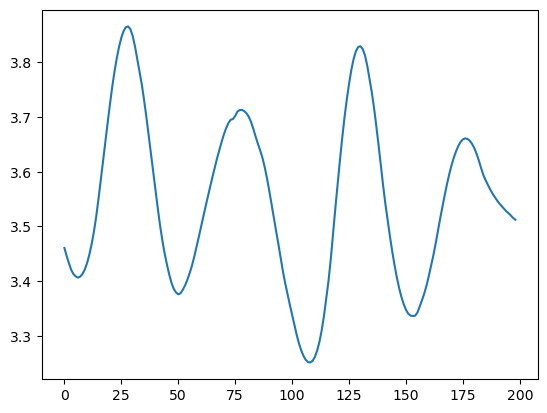

In [7]:
gap = energies[:,1]-energies[:,0]
print(gap)
plt.plot(gap)

### 7.2. Gap fluctuation

[-0.08835296 -0.10317796 -0.11628296 -0.12852796 -0.13633796 -0.14055796
 -0.14272796 -0.14067296 -0.13565296 -0.12736796 -0.11566296 -0.09988796
 -0.08063796 -0.05785296 -0.03039796  0.00210204  0.03708204  0.07132204
  0.10548704  0.14044204  0.17431204  0.20606204  0.23421204  0.25839204
  0.27935704  0.29614204  0.30826704  0.31530704  0.31660704  0.31149704
  0.29907704  0.28016204  0.25712204  0.23461204  0.21039704  0.18164704
  0.15108704  0.11771704  0.08272704  0.04955704  0.01755204 -0.01567796
 -0.04678296 -0.07414796 -0.09788796 -0.11811796 -0.13630796 -0.15177296
 -0.16308796 -0.16975296 -0.17322296 -0.17132796 -0.16472796 -0.15678296
 -0.14655296 -0.13452296 -0.12107296 -0.10492796 -0.08706796 -0.06866296
 -0.04977296 -0.03091796 -0.01245796  0.00555204  0.02358704  0.04102704
  0.05806704  0.07485204  0.09029704  0.10496204  0.11879204  0.13038204
  0.13982704  0.14609204  0.14724704  0.15290204  0.16110704  0.16372704
  0.16397204  0.16177204  0.15762704  0.15109204  0

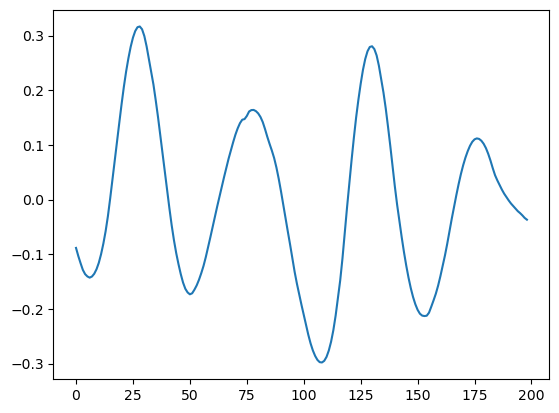

In [8]:
dE = gap - np.mean(gap)
print(dE)
plt.plot(dE)

### 7.3. Autocorrelation function of the gap fluctuation

[ 2.46818571e-02  2.45824075e-02  2.40773757e-02  2.31750948e-02
  2.18899749e-02  2.02449112e-02  1.82692672e-02  1.59976925e-02
  1.34711750e-02  1.07348437e-02  7.83743135e-03  4.83049128e-03
  1.76773480e-03 -1.29676270e-03 -4.30958679e-03 -7.21825596e-03
 -9.97225283e-03 -1.25261132e-02 -1.48406697e-02 -1.68809880e-02
 -1.86166067e-02 -2.00236022e-02 -2.10843443e-02 -2.17875967e-02
 -2.21284864e-02 -2.21078728e-02 -2.17324821e-02 -2.10146742e-02
 -1.99723444e-02 -1.86285511e-02 -1.70107793e-02 -1.51504452e-02
 -1.30814925e-02 -1.08391465e-02 -8.45855605e-03 -5.97754287e-03
 -3.43624529e-03 -8.73472325e-04  1.67186216e-03  4.16205668e-03
  6.56261960e-03  8.84059816e-03  1.09634382e-02  1.29022337e-02
  1.46326611e-02  1.61349537e-02  1.73921713e-02  1.83891832e-02
  1.91152086e-02  1.95642315e-02  1.97340590e-02  1.96252688e-02
  1.92433486e-02  1.85968393e-02  1.76955325e-02  1.65528660e-02
  1.51849838e-02  1.36100980e-02  1.18495963e-02  9.92692612e-03
  7.86663278e-03  5.69463

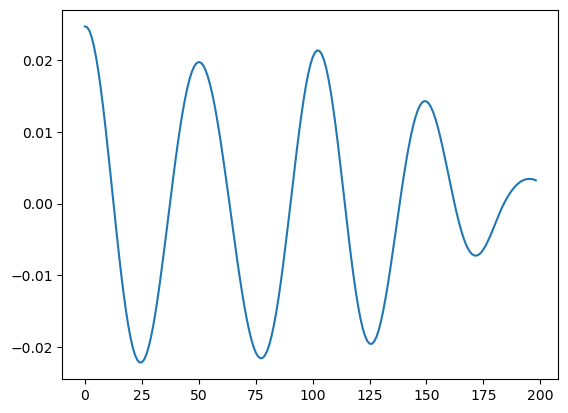

In [9]:
C = np.correlate(dE, dE, mode='full')
C = C[len(C)//2:]
C /= np.arange(len(dE),0,-1)
print(C)
print(C.shape)
plt.plot(C)

### 7.4. Frequency plotting

In [10]:
dt = 1.0 * units.fs2au # a.u.

omega = 2*np.pi*np.fft.rfftfreq(len(C), dt) * units.au2wavn #

In [11]:
T = 300.0
kB = units.kB
beta = 1.0/(kB*T)
J = beta * omega * np.real(np.fft.rfft(C))*dt

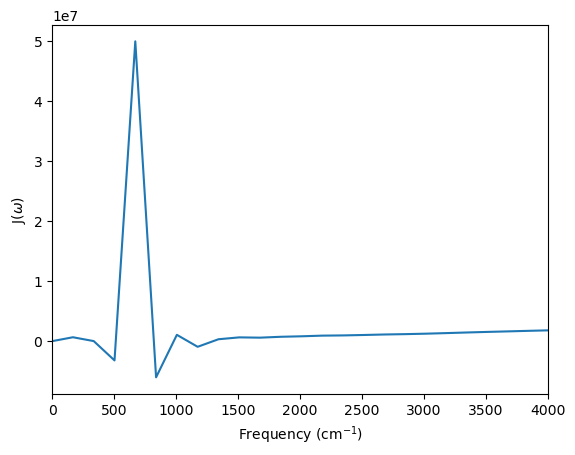

In [12]:
plt.plot(omega, J)

plt.xlim(0, 4000)   # show only 0–4000 cm^-1

plt.xlabel("Frequency (cm$^{-1}$)")
plt.ylabel("J($\omega$)")
plt.show()